# AIM 402 - Week 3 Assignment: Relate Two Variables
Variables used: **study_hours** (explanatory) and **exam_score** (response), plus **stream** as the categorical variable for the grouped comparison.

Run cells in order (Shift+Enter). Screenshot each output.

## Load data and import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

FILE_PATH = r"D:\Python_For_DataScience\Stat\assignment\nepal_student_performance.csv"
df = pd.read_csv(FILE_PATH)
print("Shape:", df.shape, "| Missing values:", df.isna().sum().sum())

x = df["study_hours"]
y = df["exam_score"]

Shape: (1200, 11) | Missing values: 0


## Scatterplot - Form, Direction, Strength

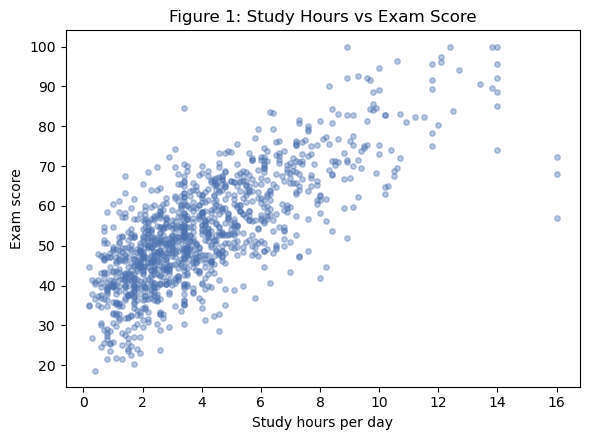

In [2]:
plt.figure(figsize=(6, 4.5))
plt.scatter(x, y, alpha=0.4, s=15, color="#4C72B0")
plt.title("Figure 1: Study Hours vs Exam Score")
plt.xlabel("Study hours per day")
plt.ylabel("Exam score")
plt.tight_layout()
plt.show()

## Pearson's r and Spearman's rho

In [3]:
pearson_r = x.corr(y, method="pearson")
spearman_rho = x.corr(y, method="spearman")

print("Pearson r  :", round(pearson_r, 4))
print("Spearman rho:", round(spearman_rho, 4))
print("Difference :", round(abs(pearson_r - spearman_rho), 4))

Pearson r  : 0.7544
Spearman rho: 0.7179
Difference : 0.0364


## Correlation matrix heatmap

                  age  study_hours  sleep_hours  attendance_pct  \
age             1.000       -0.030       -0.037          -0.016   
study_hours    -0.030        1.000        0.035           0.000   
sleep_hours    -0.037        0.035        1.000          -0.005   
attendance_pct -0.016        0.000       -0.005           1.000   
family_income  -0.060       -0.051        0.057           0.003   
exam_score     -0.035        0.754        0.124           0.188   

                family_income  exam_score  
age                    -0.060      -0.035  
study_hours            -0.051       0.754  
sleep_hours             0.057       0.124  
attendance_pct          0.003       0.188  
family_income           1.000       0.019  
exam_score              0.019       1.000  


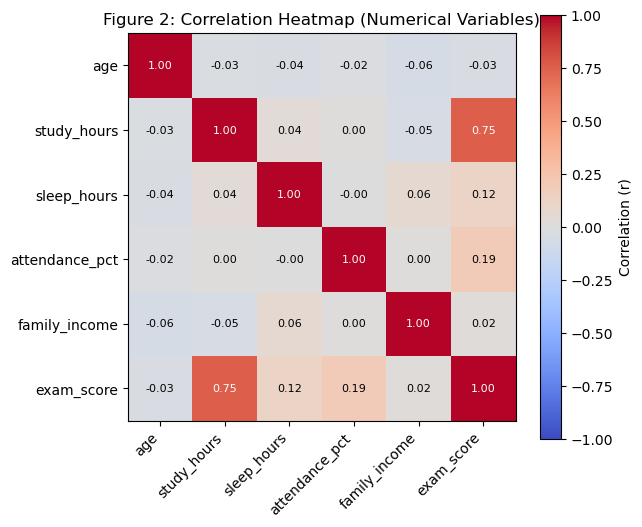

In [4]:
num_cols = df.select_dtypes("number").columns.drop("student_id").tolist()
corr_matrix = df[num_cols].corr()
print(corr_matrix.round(3))

plt.figure(figsize=(6.5, 5.5))
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="Correlation (r)")
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center",
                 color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black", fontsize=8)
plt.title("Figure 2: Correlation Heatmap (Numerical Variables)")
plt.tight_layout()
plt.show()

## Grouped boxplot and table of means (categorical x numerical)

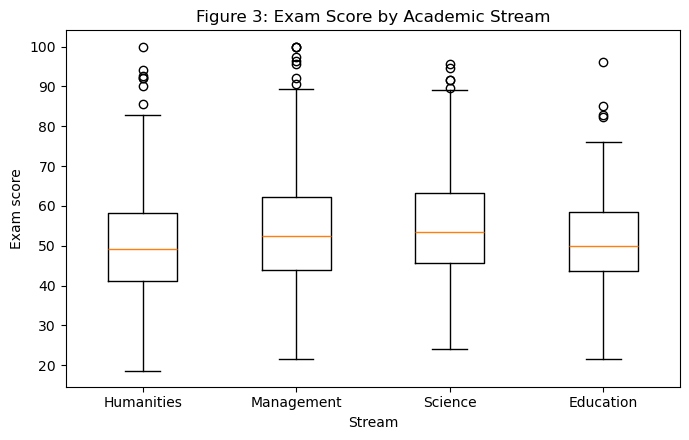

            count   mean  median    std
stream                                 
Education     153  51.68   50.00  12.42
Humanities    252  50.71   49.30  14.17
Management    442  53.63   52.35  13.94
Science       353  54.84   53.40  13.42


In [5]:
streams = df["stream"].unique().tolist()
data_by_stream = [df.loc[df["stream"] == s, "exam_score"] for s in streams]

plt.figure(figsize=(7, 4.5))
plt.boxplot(data_by_stream, tick_labels=streams)
plt.title("Figure 3: Exam Score by Academic Stream")
plt.xlabel("Stream")
plt.ylabel("Exam score")
plt.tight_layout()
plt.show()

group_table = df.groupby("stream")["exam_score"].agg(["count", "mean", "median", "std"]).round(2)
print(group_table)

## Least-squares regression line

In [6]:
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
b0, b1 = model.params

print(f"Intercept (b0): {b0:.4f}")
print(f"Slope (b1)    : {b1:.4f}")
print(f"Equation      : exam_score = {b0:.3f} + {b1:.3f} * study_hours")

Intercept (b0): 37.3250
Slope (b1)    : 3.9559
Equation      : exam_score = 37.325 + 3.956 * study_hours


## Measures of fit - R-squared, Adjusted R-squared, s_e, F-statistic

In [7]:
n = len(x)
resid = model.resid
fitted = model.fittedvalues
se = np.sqrt((resid ** 2).sum() / (n - 2))

print("R-squared         :", round(model.rsquared, 4))
print("Adjusted R-squared:", round(model.rsquared_adj, 4))
print("s_e (std. error)  :", round(se, 4))
print("F-statistic       :", round(model.fvalue, 2))
print("p-value (F)       :", model.f_pvalue)

R-squared         : 0.5691
Adjusted R-squared: 0.5687
s_e (std. error)  : 9.0158
F-statistic       : 1582.11
p-value (F)       : 3.072204403929698e-221


## Residual diagnostics

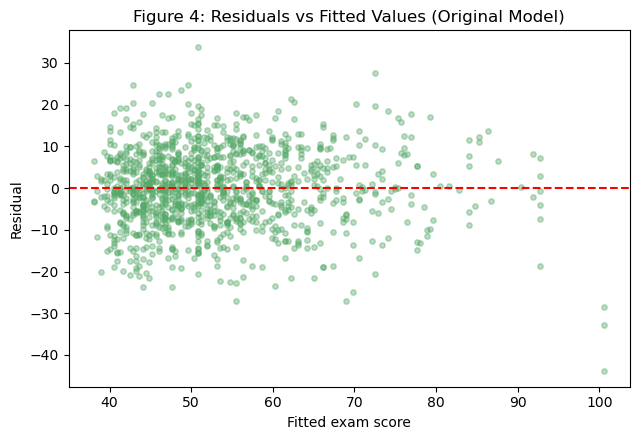

Correlation of |residual| with fitted (funnel check): 0.1107


In [8]:
plt.figure(figsize=(6.5, 4.5))
plt.scatter(fitted, resid, alpha=0.4, s=15, color="#55A868")
plt.axhline(0, color="red", linestyle="--")
plt.title("Figure 4: Residuals vs Fitted Values (Original Model)")
plt.xlabel("Fitted exam score")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

print("Correlation of |residual| with fitted (funnel check):",
      round(np.corrcoef(fitted, resid.abs())[0, 1], 4))

##  Log transformation and refit

Log-scale equation: log(exam_score) = 3.6546 + 0.0711 * study_hours
R-squared (log)         : 0.4966
Adjusted R-squared (log): 0.4962
s_e (log scale)         : 0.1876
Percent change in exam_score per 1 unit of study_hours: 7.37 %


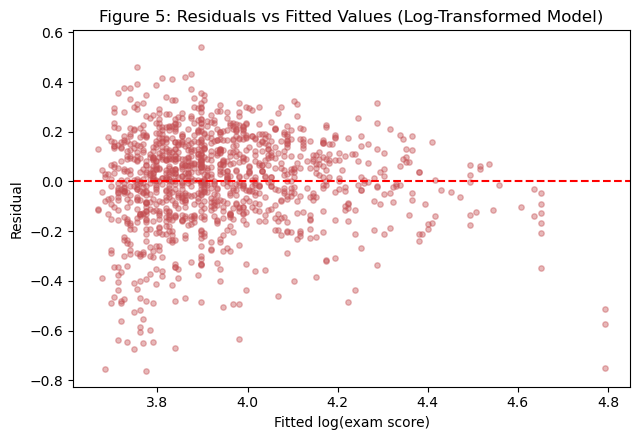

In [12]:
y_log = np.log(y)
model_log = sm.OLS(y_log, X).fit()
b0_log, b1_log = model_log.params
resid_log = model_log.resid
fitted_log = model_log.fittedvalues
se_log = np.sqrt((resid_log ** 2).sum() / (n - 2))

print(f"Log-scale equation: log(exam_score) = {b0_log:.4f} + {b1_log:.4f} * study_hours")
print("R-squared (log)         :", round(model_log.rsquared, 4))
print("Adjusted R-squared (log):", round(model_log.rsquared_adj, 4))
print("s_e (log scale)         :", round(se_log, 4))
print("Percent change in exam_score per 1 unit of study_hours:",
      round((np.exp(b1_log) - 1) * 100, 2), "%")

plt.figure(figsize=(6.5, 4.5))
plt.scatter(fitted_log, resid_log, alpha=0.4, s=15, color="#C44E52")
plt.axhline(0, color="red", linestyle="--")
plt.title("Figure 5: Residuals vs Fitted Values (Log-Transformed Model)")
plt.xlabel("Fitted log(exam score)")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

Predictions (inside and outside the observed range)

In [13]:
x_in = 7     # inside the observed range (0.2 to 16)
x_out = 30   # well outside the observed range

pred_in = b0 + b1 * x_in
pred_out = b0 + b1 * x_out

print("Observed range of study_hours:", x.min(), "to", x.max())
print(f"Predicted exam_score at study_hours = {x_in} (inside range) :", round(pred_in, 2))
print(f"Predicted exam_score at study_hours = {x_out} (outside range):", round(pred_out, 2))

Observed range of study_hours: 0.2 to 16.0
Predicted exam_score at study_hours = 7 (inside range) : 65.02
Predicted exam_score at study_hours = 30 (outside range): 156.0
